# Tomato Leaf Disease Classification — MobileNetV2

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Config


In [2]:
DATA_DIR = "/kaggle/input/datasets/ghadagsme/final-tomato-dataset/grad project"  

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)

In [3]:
!pip install split-folders --quiet

In [ ]:
import splitfolders

splitfolders.ratio(
    DATA_DIR,           
    output="/kaggle/working/split_data",
    seed=SEED,
    ratio=(0.7, 0.15, 0.15),  
)

Copying files: 13103 files [02:03, 106.30 files/s]


## Data generators (train / validation split)

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,         
    width_shift_range=0.1,     
    height_shift_range=0.1,        
    zoom_range=0.15,        
    horizontal_flip=True,  
    brightness_range=[0.9, 1.1],
    fill_mode="nearest",     
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)  

train_gen = train_datagen.flow_from_directory(
    "/kaggle/working/split_data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=SEED,
    shuffle=True,
)

val_gen = val_test_datagen.flow_from_directory(
    "/kaggle/working/split_data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=SEED,
    shuffle=False,
)

test_gen = val_test_datagen.flow_from_directory(
    "/kaggle/working/split_data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=SEED,
    shuffle=False,
)

Found 9167 images belonging to 8 classes.
Found 1961 images belonging to 8 classes.
Found 1974 images belonging to 8 classes.


In [6]:
import json

class_indices_map = {v: k for k, v in train_gen.class_indices.items()}  # index -> class name

with open("/kaggle/working/class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_indices_map, f, ensure_ascii=False, indent=2)

print(class_indices_map)

{0: 'Tomato_Bacterial_spot', 1: 'Tomato_Leaf_Mold', 2: 'Tomato_Septoria_leaf_spot', 3: 'Tomato_Spider_mites_Two_spotted_spider_mite', 4: 'Tomato__Target_Spot', 5: 'Tomato__Tomato_YellowLeaf__Curl_Virus', 6: 'Tomato__Tomato_mosaic_virus', 7: 'Tomato_healthy'}


## Build model

In [13]:
num_classes = train_gen.num_classes
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Stage 1 — train the classifier head (base frozen)

In [14]:
checkpoint_stage1 = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/mobilenetv2_stage1_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)

history_stage1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[checkpoint_stage1, early_stop],
)

model.save("/kaggle/working/mobilenetv2_stage1_final.keras")
print("Stage 1 complete. Model saved to /kaggle/working/mobilenetv2_stage1_final.keras")

Epoch 1/30


2026-09-16 16:30:27.829860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 16:30:27.981310: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789576230.880478     157 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


108/287 ━━━━━━━━━━━━━━━━━━━━ 1:12 404ms/step - accuracy: 0.5058 - loss: 1.3702

2026-09-16 16:31:24.154220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 16:31:24.290817: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6369 - loss: 1.0206

2026-09-16 16:32:55.301195: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 16:32:55.437223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.87710, saving model to /kaggle/working/mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_stage1_best.keras
287/287 ━━━━━━━━━━━━━━━━━━━━ 170s 514ms/step - accuracy: 0.7522 - loss: 0.7033 - val_accuracy: 0.8771 - val_loss: 0.3508
Epoch 2/30
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.8354 - loss: 0.4616
Epoch 2: val_accuracy did not improve from 0.87710
287/287 ━━━━━━━━━━━━━━━━━━━━ 119s 413ms/step - accuracy: 0.8393 - loss: 0.4456 - val_accuracy: 0.8756 - val_loss: 0.3532
Epoch 3/30
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.8638 - loss: 0.3874
Epoch 3: val_accuracy improved from 0.87710 to 0.88322, saving model to /kaggle/working/mobilenetv2_stage1_best.keras

Epoch 3: finished saving model to /kaggle/working/mobilenetv2_stage1_best.keras
287/287 ━━━━━━━━━━━━━━━━━━━━ 118s 412ms/step - accuracy: 0.8636 - loss: 0.3858 - val_accuracy: 0.8832 - val_loss: 0.3197
Epoch 4/30
287

## Stage 2 — fine-tune the top layers of the base



In [15]:
# Uncomment if resuming from a saved Stage 1 model instead of running Stage 1 above:
# model = tf.keras.models.load_model("/kaggle/input/<your-stage1-dataset>/mobilenetv2_stage1_final.keras")
# base_model = model.get_layer("mobilenetv2_1.00_224")  # check exact layer name via model.summary()

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30  # unfreeze last ~30 layers
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


checkpoint_stage2 = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/mobilenetv2_finetuned_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=0,
)

history_stage2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_stage2, early_stop],
    
)

model.save("/kaggle/working/mobilenetv2_finetuned_final.keras")
print("Stage 2 complete. Model saved to /kaggle/working/mobilenetv2_finetuned_final.keras")

Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 155s 477ms/step - accuracy: 0.8655 - loss: 0.4347 - val_accuracy: 0.7139 - val_loss: 2.2329
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 118s 410ms/step - accuracy: 0.9364 - loss: 0.2013 - val_accuracy: 0.7282 - val_loss: 2.7475
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 120s 417ms/step - accuracy: 0.9468 - loss: 0.1641 - val_accuracy: 0.7068 - val_loss: 2.3636
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 115s 402ms/step - accuracy: 0.9528 - loss: 0.1542 - val_accuracy: 0.8613 - val_loss: 0.9935
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 116s 404ms/step - accuracy: 0.9621 - loss: 0.1215 - val_accuracy: 0.9373 - val_loss: 0.3298
Epoch 6/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 120s 417ms/step - accuracy: 0.9681 - loss: 0.1067 - val_accuracy: 0.8929 - val_loss: 0.4108
Epoch 7/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 118s 412ms/step - accuracy: 0.9691 - loss: 0.0974 - val_accuracy: 0.9087 - val_loss: 0.5507
Stage 2 complete. Model saved to /kaggle/working/mobilenetv2_finetuned_final

## Quick check: training curves

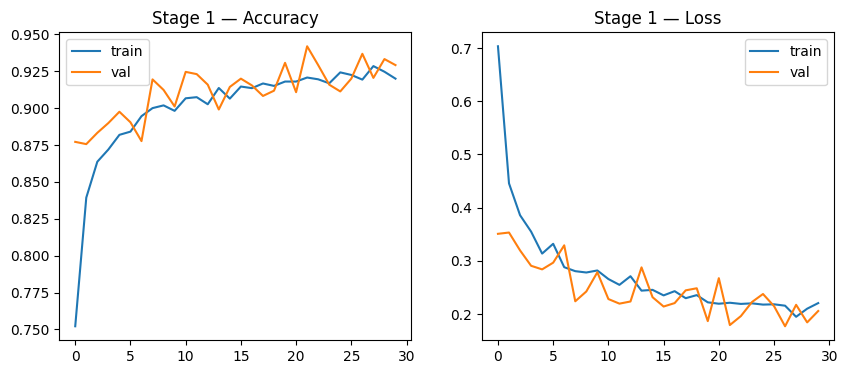

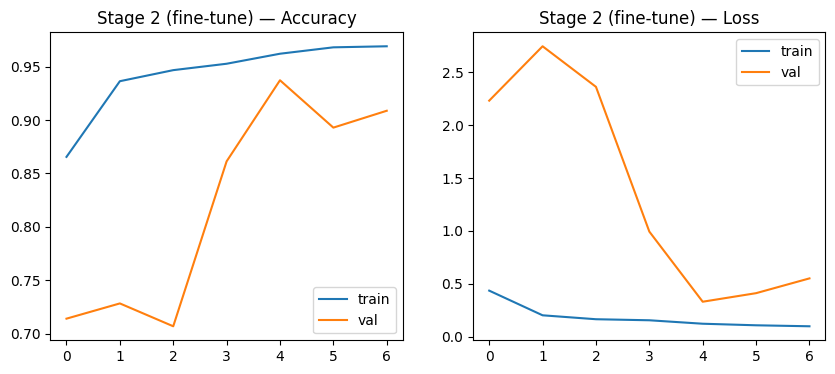

In [16]:
import matplotlib.pyplot as plt

for h, title in [(history_stage1, "Stage 1"), (history_stage2, "Stage 2 (fine-tune)")]:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h.history["accuracy"], label="train")
    plt.plot(h.history["val_accuracy"], label="val")
    plt.title(f"{title} — Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h.history["loss"], label="train")
    plt.plot(h.history["val_loss"], label="val")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Load the best checkpoint (safer than relying on whatever's in memory)
eval_model = tf.keras.models.load_model("/kaggle/working/mobilenetv2_stage1_best.keras")


y_pred_probs = eval_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 124ms/step


In [25]:
val_gen.class_indices

{'Tomato_Bacterial_spot': 0,
 'Tomato_Leaf_Mold': 1,
 'Tomato_Septoria_leaf_spot': 2,
 'Tomato_Spider_mites_Two_spotted_spider_mite': 3,
 'Tomato__Target_Spot': 4,
 'Tomato__Tomato_YellowLeaf__Curl_Virus': 5,
 'Tomato__Tomato_mosaic_virus': 6,
 'Tomato_healthy': 7}

In [26]:
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot      0.978     0.956     0.967       320
                           Tomato_Leaf_Mold      0.904     0.979     0.940       144
                  Tomato_Septoria_leaf_spot      0.938     0.899     0.918       267
Tomato_Spider_mites_Two_spotted_spider_mite      0.939     0.909     0.923       252
                        Tomato__Target_Spot      0.904     0.844     0.873       212
      Tomato__Tomato_YellowLeaf__Curl_Virus      0.971     0.985     0.978       482
                Tomato__Tomato_mosaic_virus      0.964     0.930     0.946        57
                             Tomato_healthy      0.905     0.992     0.946       240

                                   accuracy                          0.943      1974
                                  macro avg      0.938     0.937     0.937      1974
                               weighted avg      0.943     0.94

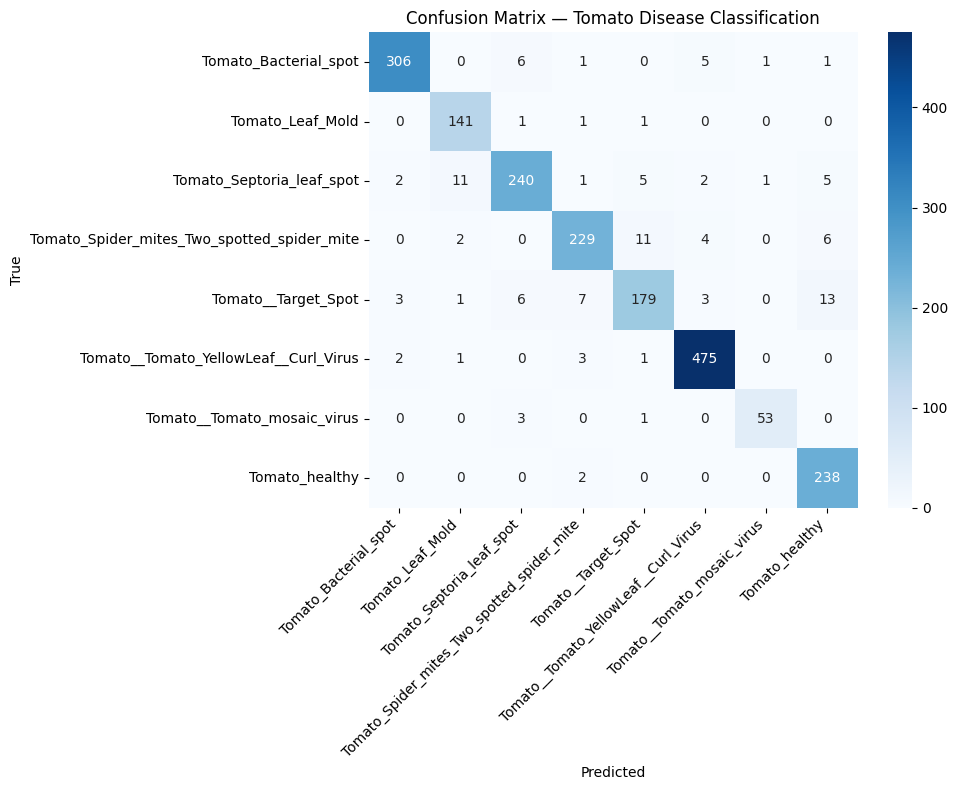

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix — Tomato Disease Classification")
plt.tight_layout()
plt.show()

In [31]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [ ]:
if uploader.value:
   
    if isinstance(uploader.value, tuple):
        file_info = uploader.value[0]
        name, content = file_info['name'], file_info['content']
    else:
        name = list(uploader.value.keys())[0]
        content = uploader.value[name]['content']

    image_path = f"/kaggle/working/{name}"
    with open(image_path, 'wb') as f:
        f.write(content)

    print("Saved to:", image_path)
else:
    print("imgae not uploaded yet")

Saved to: /kaggle/working/WhatsApp Image 2026-09-16 at 21.30.24.jpeg


In [45]:
"""
Treatment Recommendation Engine — Tomato Leaf Diseases (English)
----------------------------------------------------------------------------
IMPORTANT: General agricultural guidance based on common practice, not a
substitute for a local agricultural extension officer/agronomist —
say so in your app UI, especially for severe or spreading infections.
"""

from dataclasses import dataclass, field
from typing import List


from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


@dataclass
class TreatmentInfo:
    disease_name: str
    severity: str  
    urgency: str
    immediate_actions: List[str] = field(default_factory=list)
    organic_treatment: List[str] = field(default_factory=list)
    chemical_treatment: List[str] = field(default_factory=list)
    prevention: List[str] = field(default_factory=list)


TREATMENT_DB = {
    "Tomato_Bacterial_spot": TreatmentInfo(
        disease_name="Bacterial Spot",
        severity="medium",
        urgency="Spreads quickly in warm, humid conditions — act within 2 days",
        immediate_actions=[
            "Remove clearly infected leaves and destroy/dispose away from the field",
            "Reduce overhead watering; switch to drip irrigation if possible",
        ],
        organic_treatment=[
            "Apply copper-based bactericides on a regular schedule",
            "Improve airflow between plants to lower humidity",
        ],
        chemical_treatment=["Copper + mancozeb mix, following locally recommended dosage"],
        prevention=[
            "Crop rotation — avoid planting tomatoes in the same soil two years running",
            "Use certified disease-free seeds/seedlings",
        ],
    ),
  
    "Tomato_Leaf_Mold": TreatmentInfo(
        disease_name="Leaf Mold",
        severity="low",
        urgency="Relatively slow-spreading but weakens the crop — act within a week",
        immediate_actions=["Improve ventilation immediately", "Lower ambient humidity around the plant"],
        organic_treatment=["Sulfur-based fungicide spray"],
        chemical_treatment=["Chlorothalonil-based fungicide if needed"],
        prevention=["Good greenhouse ventilation", "Avoid overly dense planting"],
    ),
    "Tomato_Septoria_leaf_spot": TreatmentInfo(
        disease_name="Septoria Leaf Spot",
        severity="medium",
        urgency="Spreads from lower leaves upward — act within 3-4 days",
        immediate_actions=["Remove infected lower leaves immediately", "Clear away any infected plant debris"],
        organic_treatment=["Regular copper spray every 7-10 days during humid seasons"],
        chemical_treatment=["Mancozeb or chlorothalonil per local dosage guidance"],
        prevention=["At least 2-year crop rotation away from tomatoes", "Mulch to prevent soil-splash spread"],
    ),
    "Tomato_Spider_mites_Two_spotted_spider_mite": TreatmentInfo(
        disease_name="Two-Spotted Spider Mite",
        severity="medium",
        urgency="A pest, not a fungus/bacteria — spreads fast in hot, dry weather, act within 2-3 days",
        immediate_actions=["Check the undersides of leaves to confirm", "Spray plant with strong water jet to remove mites mechanically"],
        organic_treatment=["Neem oil or insecticidal soap", "Release natural predators (predatory mites) if feasible"],
        chemical_treatment=["Specialized miticides — regular insecticides usually don't work on mites"],
        prevention=["Maintain reasonable humidity", "Regularly inspect leaf undersides"],
    ),
    "Tomato__Target_Spot": TreatmentInfo(
        disease_name="Target Spot",
        severity="medium",
        urgency="Spreads in high humidity — act within 3-4 days",
        immediate_actions=["Remove visibly infected leaves/fruit", "Reduce how long leaves stay wet"],
        organic_treatment=["Regular copper spray"],
        chemical_treatment=["Fungicides with azoxystrobin or chlorothalonil"],
        prevention=["Good ventilation and adequate plant spacing", "Remove surrounding weeds"],
    ),
    "Tomato__Tomato_YellowLeaf__Curl_Virus": TreatmentInfo(
        disease_name="Tomato Yellow Leaf Curl Virus",
        severity="high",
        urgency="Viral, transmitted by whiteflies — no direct cure, focus on stopping spread immediately",
        immediate_actions=["Remove the entire infected plant, roots included, immediately", "Dispose away from the rest of the crop"],
        organic_treatment=["No organic cure for the virus itself — focus on controlling the whitefly vector"],
        chemical_treatment=["Insecticides targeting whiteflies to prevent spread to other plants"],
        prevention=["Insect netting on greenhouses", "Virus-resistant varieties next planting", "Proactive whitefly control"],
    ),
    "Tomato__Tomato_mosaic_virus": TreatmentInfo(
        disease_name="Tomato Mosaic Virus",
        severity="high",
        urgency="Viral and highly contact-contagious — act immediately to prevent spread",
        immediate_actions=[
            "Remove the infected plant immediately, roots included",
            "Sterilize any tools that touched it before using on other plants",
            "Wash hands thoroughly after handling the infected plant",
        ],
        organic_treatment=["No cure for the virus itself — focus solely on preventing spread"],
        chemical_treatment=["No chemical cures the virus — focus on isolation and sanitation"],
        prevention=["Certified virus-free seeds", "Sterilize tools between plants", "Avoid smoking near plants (virus can transfer from tobacco)"],
    ),
    "Tomato_healthy": TreatmentInfo(
        disease_name="Healthy",
        severity="low",
        urgency="No action required",
        immediate_actions=["Continue routine monitoring"],
        organic_treatment=[],
        chemical_treatment=[],
        prevention=["Maintain current watering and fertilizing practices"],
    ),
}


def get_recommendation(predicted_class: str, confidence: float, low_conf_threshold: float = 0.6,
                        medium_conf_threshold: float = 0.85) -> dict:
    """
    Returns an English recommendation dict.
    """
    if predicted_class not in TREATMENT_DB:
        return {
            "status": "unknown_class",
            "message": "Class not found in the knowledge base — check the class name sent by the model.",
        }

    info = TREATMENT_DB[predicted_class]

    if confidence < low_conf_threshold:
        return {
            "status": "low_confidence",
            "predicted_class": predicted_class,
            "confidence": confidence,
            "message": (
                f"The model isn't confident enough (below {int(low_conf_threshold * 100)}%). "
                "Try a clearer photo or consult an expert before taking action."
            ),
        }

    if confidence >= medium_conf_threshold:
        confidence_note = "The model is highly confident."
    else:
        confidence_note = "Moderate confidence — visual confirmation is recommended before chemical treatment."

    return {
        "status": "ok",
        "predicted_class": predicted_class,
        "confidence": confidence,
        "confidence_note": confidence_note,
        "severity": info.severity,
        "disease_name": info.disease_name,
        "urgency": info.urgency,
        "immediate_actions": info.immediate_actions,
        "organic_treatment": info.organic_treatment,
        "chemical_treatment": info.chemical_treatment,
        "prevention": info.prevention,
    }


# ---------------------------------------------------------
# Model loading + image prediction
# ---------------------------------------------------------
IMG_SIZE = (224, 224)




with open("/kaggle/working/class_indices.json", "r", encoding="utf-8") as f:
    CLASS_INDICES = {int(k): v for k, v in json.load(f).items()}


def load_trained_model(model_path: str = "/kaggle/working/mobilenetv2_stage1_best.keras"):
    return tf.keras.models.load_model(model_path)


def predict_image(model, image_path: str) -> tuple[str, float]:
    """
    Loads an image, preprocesses it exactly like training (resize + MobileNetV2
    preprocess_input), runs prediction, and returns (predicted_class, confidence).
    """
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]
    predicted_index = int(np.argmax(preds))
    confidence = float(preds[predicted_index])
    predicted_class = CLASS_INDICES[predicted_index]

    return predicted_class, confidence


# ---------------------------------------------------------
# Example usage: predict -> get treatment
# ---------------------------------------------------------
if __name__ == "__main__":
    model = load_trained_model("/kaggle/working/mobilenetv2_stage1_best.keras")  

    image_path2 = image_path  # <-- change this to your image path
    predicted_class, confidence = predict_image(model, image_path2)

    recommendation = get_recommendation(predicted_class, confidence)

    import json
    print(json.dumps(recommendation, ensure_ascii=False, indent=2))

{
  "status": "low_confidence",
  "predicted_class": "Tomato_healthy",
  "confidence": 0.44054827094078064,
  "message": "The model isn't confident enough (below 60%). Try a clearer photo or consult an expert before taking action."
}
